In [121]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from swissclim_evaluations.metrics import crps_ensemble, probability_integral_transform, ensemble_mean_se, ensemble_std
from swissclim_evaluations.helpers import time_chunks, patch_time_dimensions
from swissclim_evaluations.aggregations import histogram, latitude_weights

In [122]:

PATH_ML = "/capstor/store/cscs/swissai/a01/ESFM_Results/preds_20250219/aurora_tail.zarr"
PATH_ERA5 = "/capstor/store/cscs/ERA5/weatherbench2_original"

DATETIMES = np.array(["2021-01-01T12", "2021-02-01T06"], dtype="datetime64")
LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
VARIABLES_2D = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "mean_sea_level_pressure",
]
VARIABLES_3D = [
    "geopotential",
    "specific_humidity",
    "temperature",
    "u_component_of_wind",
    "v_component_of_wind",
]

In [124]:
# open and reformat forecast data
fct = xr.open_zarr(PATH_ML)[VARIABLES_2D]
fct = fct.sel(time=slice(DATETIMES[0] + np.timedelta64(6, "h"), DATETIMES[1] ))


fct = patch_time_dimensions(fct)
fct

<xarray.Dataset> Size: 97GB
Dimensions:                  (lead_time: 1, init_time: 733, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 6kB 2021-0...
  * init_time                (init_time) datetime64[ns] 6kB 2021-01-01T12:00:...
Data variables:
    10m_u_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 24GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    10m_v_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 24GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    2m_temperature           (init_time, lead_time, ensemble, latitude, longitude) float32 24GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    mean_sea_level_pressure  (init_time, lead_time, ensemble, latitude, longitude) float32 24GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>

In [125]:
era5 = xr.open_zarr(PATH_ERA5)[VARIABLES_2D]
era5 = era5.sel(time=slice(*DATETIMES))
era5 = era5.rename({"time": "valid_time"})
era5

<xarray.Dataset> Size: 12GB
Dimensions:                  (valid_time: 739, latitude: 721, longitude: 1440)
Coordinates:
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.75 -90.0
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
  * valid_time               (valid_time) datetime64[ns] 6kB 2021-01-01T12:00...
Data variables:
    10m_u_component_of_wind  (valid_time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind  (valid_time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature           (valid_time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    mean_sea_level_pressure  (valid_time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>

In [126]:
era5, fct = xr.align(era5, fct, join="inner")

In [ ]:
init_times = fct["init_time"].values
lead_times = fct["lead_time"].values


temporal_aggregations = None
spatial_aggregations = []
weights = latitude_weights(era5["latitude"])

chunks = time_chunks(init_times, lead_times, 20, 1)
i = 0
for chunk_times in chunks:
    n_init_times, n_lead_times = len(chunk_times[0]), len(chunk_times[1])
    print(f"Computing probabilistic verification for chunk "
          f"{i+1}/{len(init_times)} containing {n_init_times} init times and {n_lead_times} lead times")
    
    # get chunks of forecast and era5 data
    fct_chunk = fct.sel(init_time=chunk_times[0], lead_time=chunk_times[1]).chunk({"init_time": 1}).persist()
    era5_chunk = era5.sel(valid_time=fct_chunk["valid_time"]).chunk({"init_time": 1}).persist()
    fct_sizeof, era5_sizeof = fct_chunk.nbytes / 1e9, era5_chunk.nbytes / 1e9
    # print(f"    Loaded chunks: fct {fct_sizeof:.2f} GB, {era5_sizeof:.2f} GB")

    # compute pointwise metrics and statistics
    crps = crps_ensemble(era5_chunk, fct_chunk)
    pit = probability_integral_transform(era5_chunk, fct_chunk)
    metrics = xr.merge([crps, pit])
    
    ens_std = ensemble_std(fct_chunk)
    ens_mean_se = ensemble_mean_se(era5_chunk, fct_chunk)
    statistics = xr.merge([ens_std, ens_mean_se])

    if temporal_aggregations is None:
        temporal_aggregations = metrics.mean(["init_time"]).compute()
    else:
        temporal_aggregations += metrics.mean(["init_time"]).compute()

    spatial_aggregations.append(metrics.weighted(weights).mean(["latitude", "longitude"]).compute())

    if i > 10:
        break

    i += 1

temporal_aggregations /= (i + 1)
spatial_aggregations = xr.merge(spatial_aggregations)

Computing probabilistic verification for chunk 1/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 2/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 3/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 4/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 5/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 6/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 7/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 8/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 9/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 10/733 containing 20 init times and 1 lead times
Computing probabilistic verification for chunk 11

In [ ]:
metrics.

<xarray.Dataset> Size: 995MB
Dimensions:                       (init_time: 20, lead_time: 1, latitude: 720,
                                   longitude: 1440)
Coordinates:
  * latitude                      (latitude) float32 3kB 90.0 89.75 ... -89.75
  * longitude                     (longitude) float32 6kB 0.0 0.25 ... 359.8
    valid_time                    (init_time, lead_time) datetime64[ns] 160B dask.array<chunksize=(1, 1), meta=np.ndarray>
  * lead_time                     (lead_time) timedelta64[ns] 8B 06:00:00
  * init_time                     (init_time) datetime64[ns] 160B 2021-01-10T...
Data variables:
    CRPS.10m_u_component_of_wind  (init_time, lead_time, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    CRPS.10m_v_component_of_wind  (init_time, lead_time, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    CRPS.2m_temperature           (init_time, lead_time, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    CRPS.mean_sea_level_pressure  (init_time, lead_time, latitude, longitude) float32 83MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    PIT.10m_u_component_of_wind   (init_time, lead_time, latitude, longitude) float64 166MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    PIT.10m_v_component_of_wind   (init_time, lead_time, latitude, longitude) float64 166MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    PIT.2m_temperature            (init_time, lead_time, latitude, longitude) float64 166MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    PIT.mean_sea_level_pressure   (init_time, lead_time, latitude, longitude) float64 166MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>

In [132]:
xr.merge(spatial_aggregations)["CRPS.2m_temperature"]

<xarray.DataArray 'CRPS.2m_temperature' (init_time: 240, lead_time: 1)> Size: 960B
array([[1.2091588 ],
       [1.1974852 ],
       [1.1583511 ],
       [1.0930738 ],
       [1.1263399 ],
       [1.0044291 ],
       [0.9775262 ],
       [1.0207337 ],
       [1.1027129 ],
       [1.1510439 ],
       [1.0308844 ],
       [1.1858447 ],
       [1.2024255 ],
       [1.1931616 ],
       [1.2094858 ],
       [1.2864542 ],
       [1.3919985 ],
       [1.3953251 ],
       [1.4581062 ],
       [1.4177427 ],
...
       [1.1589224 ],
       [1.0406566 ],
       [1.0029377 ],
       [1.0273812 ],
       [1.0974054 ],
       [1.1188194 ],
       [0.9904014 ],
       [1.1425985 ],
       [1.1575996 ],
       [1.2011436 ],
       [1.1999067 ],
       [1.2535094 ],
       [1.4074414 ],
       [1.3569224 ],
       [1.3445002 ],
       [1.3189728 ],
       [1.2460185 ],
       [1.275041  ],
       [1.0401584 ],
       [1.1650622 ]], dtype=float32)
Coordinates:
  * lead_time   (lead_time) timedelta64[ns] 8B 06:00:00
  * init_time   (init_time) datetime64[ns] 2kB 2021-01-01T12:00:00 ... 2021-0...
    valid_time  (init_time, lead_time) datetime64[ns] 2kB 2021-01-01T12:00:00...

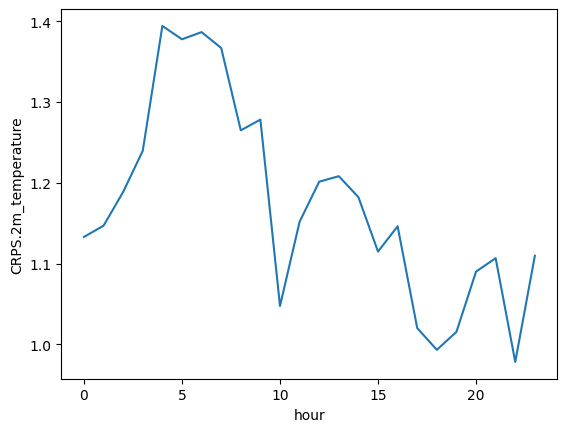

In [143]:
xr.merge(spatial_aggregations)["CRPS.2m_temperature"].groupby("valid_time.hour").mean().plot()

In [144]:


histogram(res[[var for var in res.data_vars if "PIT" in var]], bins=8, dims=["latitude","longitude"], bindim="binForPIT").compute()

<xarray.Dataset> Size: 6kB
Dimensions:                      (init_time: 20, lead_time: 1, binForPIT: 8)
Coordinates:
  * init_time                    (init_time) datetime64[ns] 160B 2021-01-10T1...
  * lead_time                    (lead_time) timedelta64[ns] 8B 06:00:00
    valid_time                   (init_time, lead_time) datetime64[ns] 160B 2...
  * binForPIT                    (binForPIT) object 64B (0.0, 0.125] ... (0.8...
Data variables:
    PIT.10m_u_component_of_wind  (init_time, lead_time, binForPIT) int64 1kB ...
    PIT.10m_v_component_of_wind  (init_time, lead_time, binForPIT) int64 1kB ...
    PIT.2m_temperature           (init_time, lead_time, binForPIT) int64 1kB ...
    PIT.mean_sea_level_pressure  (init_time, lead_time, binForPIT) int64 1kB ...

In [96]:
time_aggregations = temporal_aggregations / (i + 1)
time_aggregations

<xarray.Dataset> Size: 83MB
Dimensions:                                           (latitude: 720,
                                                       longitude: 1440,
                                                       lead_time: 1)
Coordinates:
  * latitude                                          (latitude) float32 3kB ...
  * longitude                                         (longitude) float32 6kB ...
  * lead_time                                         (lead_time) timedelta64[ns] 8B ...
Data variables: (12/16)
    CRPS.10m_u_component_of_wind                      (lead_time, latitude, longitude) float32 4MB ...
    CRPS.10m_v_component_of_wind                      (lead_time, latitude, longitude) float32 4MB ...
    CRPS.2m_temperature                               (lead_time, latitude, longitude) float32 4MB ...
    CRPS.mean_sea_level_pressure                      (lead_time, latitude, longitude) float32 4MB ...
    PIT.10m_u_component_of_wind                       (lead_time, latitude, longitude) float64 8MB ...
    PIT.10m_v_component_of_wind                       (lead_time, latitude, longitude) float64 8MB ...
    ...                                                ...
    EnsembleSTD.2m_temperature                        (lead_time, latitude, longitude) float32 4MB ...
    EnsembleSTD.mean_sea_level_pressure               (lead_time, latitude, longitude) float32 4MB ...
    EnsembleMeanSquaredError.10m_u_component_of_wind  (lead_time, latitude, longitude) float32 4MB ...
    EnsembleMeanSquaredError.10m_v_component_of_wind  (lead_time, latitude, longitude) float32 4MB ...
    EnsembleMeanSquaredError.2m_temperature           (lead_time, latitude, longitude) float32 4MB ...
    EnsembleMeanSquaredError.mean_sea_level_pressure  (lead_time, latitude, longitude) float32 4MB ...

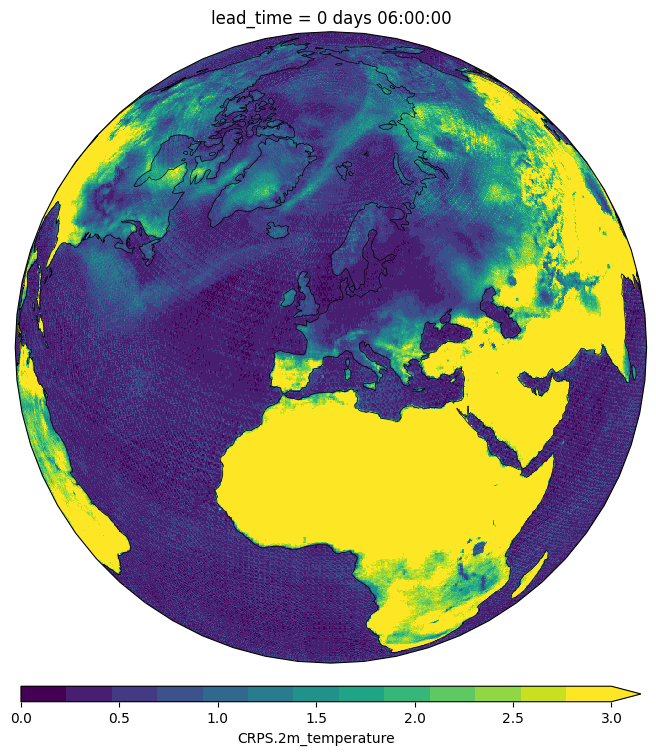

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()
proj = ccrs.Orthographic(central_longitude=5.0, central_latitude=45.0)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": proj})
ax.add_feature(cfeature.COASTLINE, ls="-", lw=0.5)
cbar_kwargs = {"aspect": 40, "extend": "max", "orientation": "horizontal", "pad": 0.03, "shrink": 0.8}
time_aggregations["CRPS.2m_temperature"][0].plot.imshow(ax=ax,
                                                        transform=ccrs.PlateCarree(),
                                                        add_colorbar=True,
                                                        cmap=plt.get_cmap("viridis", 13),
                                                        vmin=0,
                                                        cbar_kwargs=cbar_kwargs)